# 6 fósiles chinos · 1 variante que nadie había visto

De 85 dientes que probamos, solo 22 dieron señal. De esos, **6 sobrevivieron al filtro completo** — y en sus proteínas de esmalte apareció algo que no está en Neandertales, Denisovanos, ni humanos modernos. Otro detalle: una variante que sí está en Denisovanos. ¿Casualidad o puente molecular?

**Paper**: [Enamel proteins from six Homo erectus specimens across China](https://doi.org/10.1038/s41586-026-10478-8) · Nature, 2026
**Autores**: Bai, F., Wu, Z., Xing, S. & Fu, Q. et al.
**Edad**: ~400 ka (Pleistoceno Medio)
**Video**: [Pendiente]

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-13-homo-erectus-china-esmalte/notebook.ipynb)

## Qué hicieron

El equipo aplicó **paleoproteómica** — extracción de proteínas dentales fosilizadas — a 85 fósiles de tres sitios chinos: Zhoukoudian (la cueva del "Hombre de Pekín"), Hexian y Sunjiadong. El esmalte es el tejido que mejor preserva proteínas a escala de cientos de miles de años. Cuando el ADN ya se desintegró, las proteínas todavía cuentan historia.

Lo que buscaban: variantes en las proteínas del esmalte que ayuden a ubicar a estos *Homo erectus* tardíos en el árbol genealógico humano. La pregunta de fondo: ¿de dónde sale la *introgresión super-arcaica* (los pedazos de ADN heredados de un linaje humano más antiguo) que aparece en el genoma de Denisovanos?

In [1]:
# ════════════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ════════════════════════════════════════════════════════════════════
COBERTURA_REFERENCIA = 17.5    # Harbin (Fu et al. 2025, Science) — comparador
COBERTURA_PROMEDIO   = 27.1    # Media de cobertura proteómica de los 6 H. erectus chinos (mean global, n=31 mediciones)
N_TOTAL_SCREENED     = 85      # Fósiles probados con MALDI
N_FINAL_PROTEOMES    = 6       # Specimens con proteoma completo

COLOR_CHINOS    = '#2563EB'    # Azul CaM — los 6 chinos (sujetos del paper)
COLOR_HARBIN    = '#7C3AED'    # Violeta — comparador previo
COLOR_ALERTA    = '#DC2626'    # Rojo — variante A253G (la nueva)
COLOR_DENISOVA  = '#D97706'    # Amber — Denisovano (comparte M273V)
COLOR_NEAND     = '#059669'    # Emerald — Neandertal
COLOR_CONTEXTO  = '#BBBBBB'    # Gris — contexto/otros

FUENTE = 'Fuente: Bai et al. (2026) Nature · DOI: 10.1038/s41586-026-10478-8 | Datos: Supp Data 1 y 3'

# ════════════════════════════════════════════════════════════════════
import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Cargar estilo CaM (local → fallback GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file,
        )
plt.style.use(style_file)

# Carga
screening = pd.read_csv('datos/screening_resumen_sitio.csv')
cobertura = pd.read_csv('datos/cobertura_secuencias.csv')
variantes = pd.read_csv('datos/variantes_ambn.csv')
similaridad = pd.read_csv('datos/similaridad_genomica_cr4.csv')

print(f'Fósiles probados con MALDI (filtro rápido por huella molecular): {N_TOTAL_SCREENED}')
print(f'Sitios chinos: {len(screening)} ({", ".join(screening["site"])})')
print(f'Proteomas finales: {N_FINAL_PROTEOMES} chinos + 1 Harbin (comparador)')
print(f'Ventanas genómicas cr4: {len(similaridad)} (paso 2 kb, ancho 20 kb)')

Fósiles probados con MALDI (filtro rápido por huella molecular): 85
Sitios chinos: 3 (Zhoukoudian, Hexian, Sunjiadong)
Proteomas finales: 6 chinos + 1 Harbin (comparador)
Ventanas genómicas cr4: 127 (paso 2 kb, ancho 20 kb)


## Aquí está la geografía de la preservación.

Antes de mirar variantes, miremos algo más mundano: **cuántos fósiles dieron señal** en cada sitio. Porque si un sitio preserva mejor que otro, eso ya cambia qué historias podemos reconstruir.

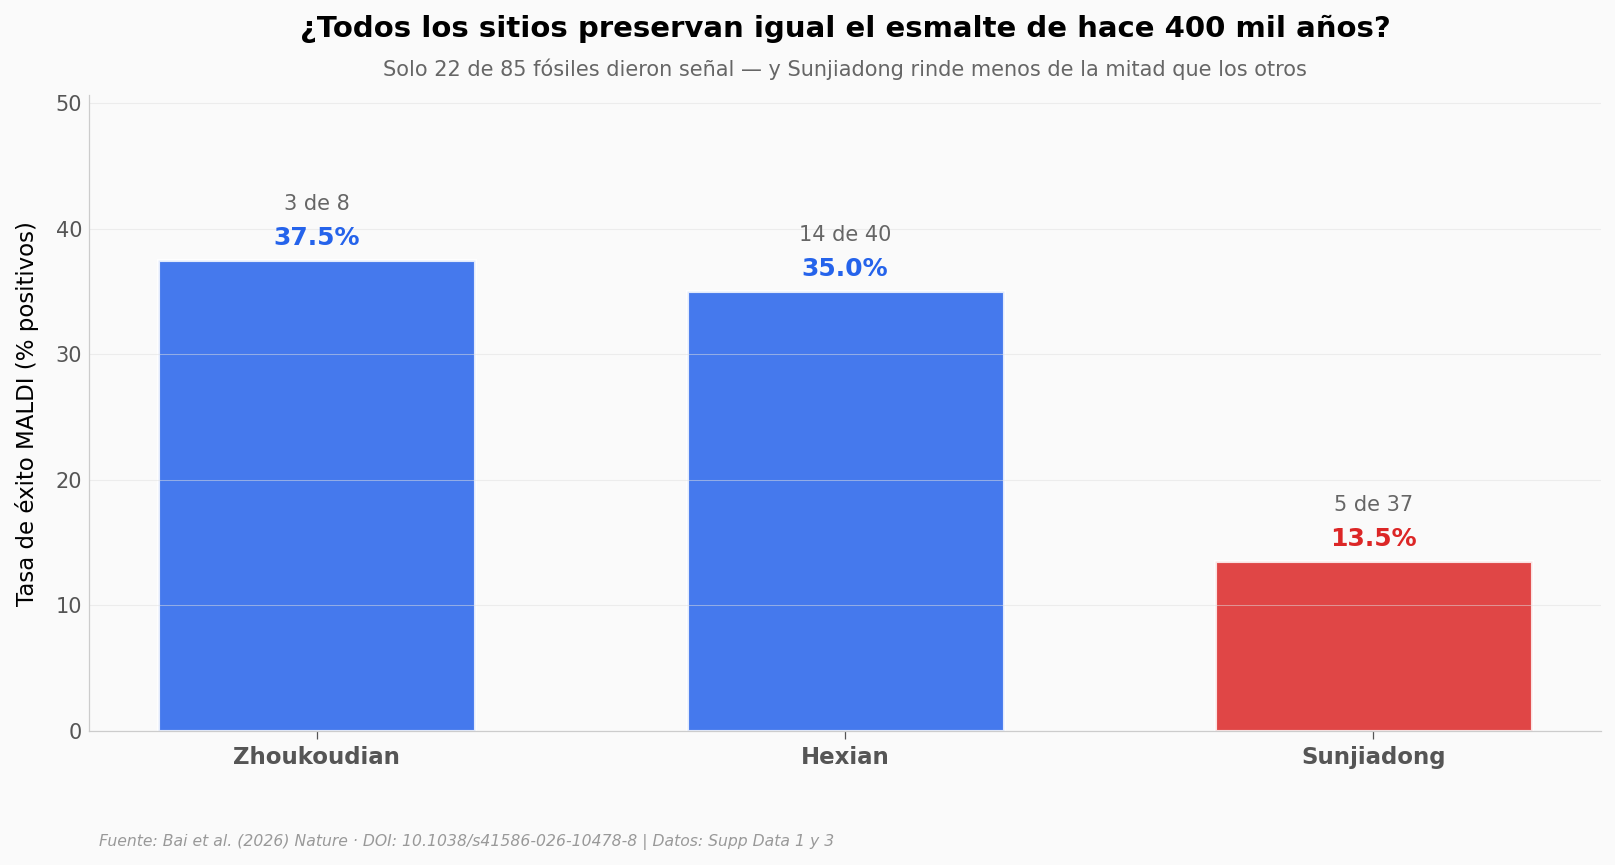

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

sites = screening['site'].tolist()
positives = screening['enamel_positive'].values
totals = screening['specimens_screened'].values
rates = screening['positive_rate_pct'].values

positions = np.arange(len(sites))
colors = [COLOR_CHINOS, COLOR_CHINOS, COLOR_ALERTA]  # Sunjiadong tasa baja → alerta

bars = ax.bar(positions, rates, color=colors, alpha=0.85, edgecolor='white', linewidth=1.5, width=0.6)

# Etiquetas valor + (positivos/total) encima de cada barra
for i, (rate, pos, tot) in enumerate(zip(rates, positives, totals)):
    ax.text(i, rate + 1.2, f'{rate:.1f}%', ha='center', fontsize=12, fontweight='bold',
            color=colors[i])
    ax.text(i, rate + 4.0, f'{pos} de {tot}', ha='center', fontsize=10, color='#666666')

ax.set_xticks(positions)
ax.set_xticklabels(sites, fontsize=11, fontweight='bold')
ax.set_ylabel('Tasa de éxito MALDI (% positivos)', fontsize=11)
ax.set_ylim(0, max(rates) * 1.35)
ax.set_title('¿Todos los sitios preservan igual el esmalte de hace 400 mil años?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Solo 22 de 85 fósiles dieron señal — y Sunjiadong rinde menos de la mitad que los otros',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/01_tasa_maldi_por_sitio.png', dpi=200, bbox_inches='tight')
plt.show()

**Zhoukoudian y Hexian rinden parecido** — alrededor de un tercio de los fósiles dieron señal. **Sunjiadong baja a un 13.5%**, casi un tercio del rendimiento de los otros dos. Eso no es ruido estadístico: es un factor de preservación del sitio. Puede ser química del sedimento, temperatura, humedad, o todas las anteriores actuando durante 400 mil años.

Para divulgación, esto importa porque suele venderse la paleoproteómica como una técnica que "funciona". Sí funciona — pero no todo el material que llega al laboratorio termina dando proteoma. De 85 fósiles que entraron al pipeline, **6 salieron al otro lado** con secuencia completa. Eso es un 7% de éxito desde el inicio.

## El zoom: qué tanta proteína recuperaron de cada uno

Cuando un specimen sobrevive el filtro MALDI y entra al pipeline LC-MS/MS (cromatografía líquida + espectrometría de masas — lectura de péptidos uno por uno), no recuperan toda la proteína completa — solo fragmentos. La métrica clave es **cobertura**: qué porcentaje de los aminoácidos teóricos de cada proteína realmente lograron leer.

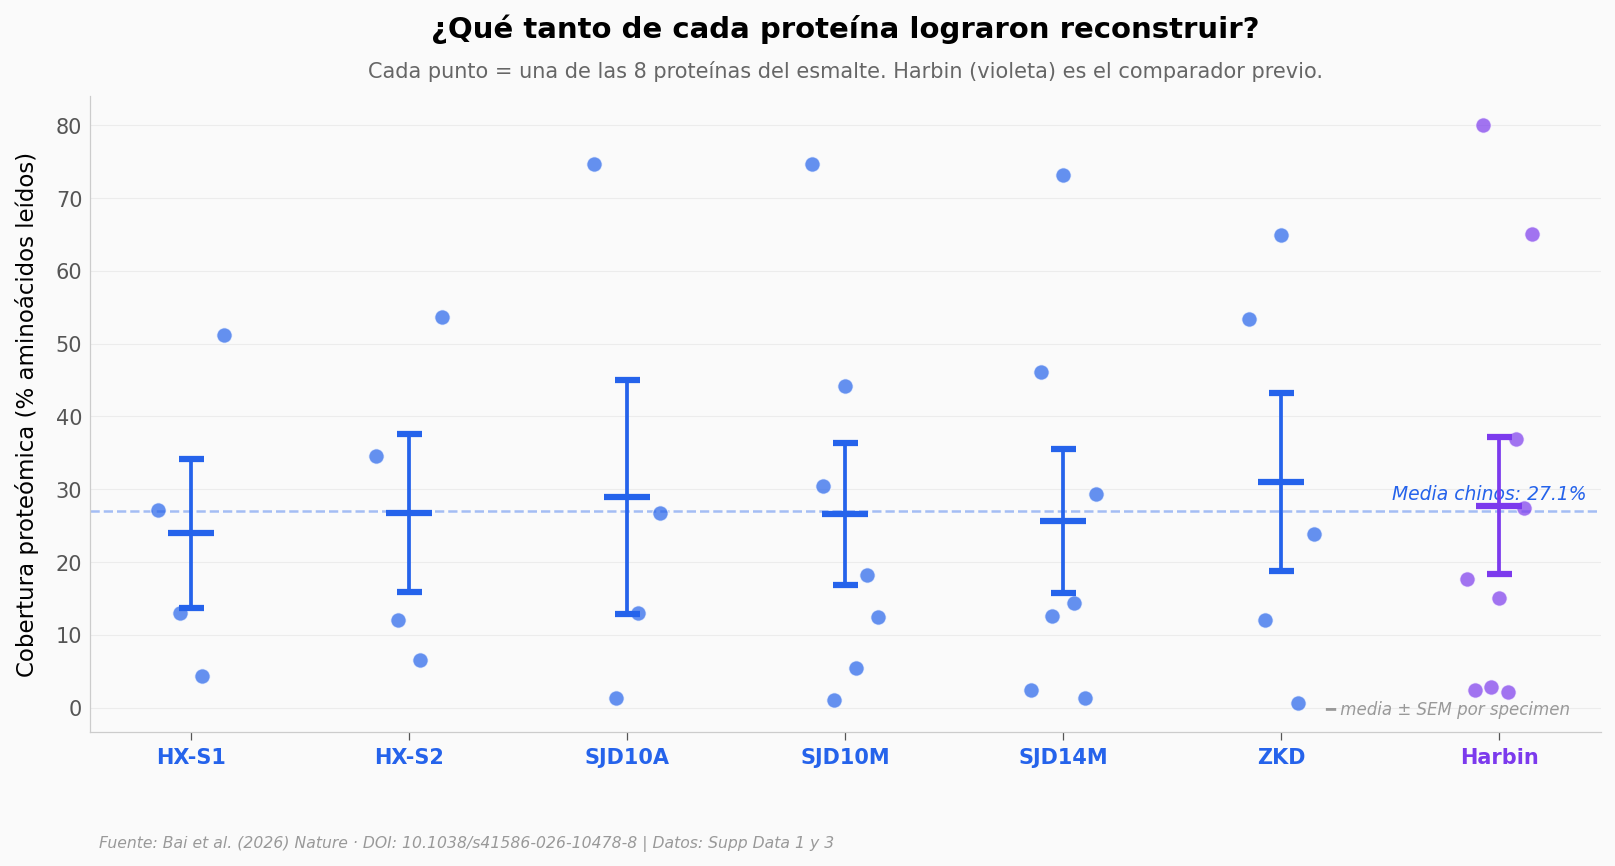

Chinos (n=31 mediciones, 6 specimens): mediana 18.2%, IQR 9.3-45.2%
Harbin (n=9 mediciones, 1 specimen):  mediana 17.7%
(Harbin: comparador descriptivo, n=1 specimen — no aplicamos test inferencial)


In [3]:
# Pivot: cobertura por specimen, agrupado
np.random.seed(42)

specimens_order = ['HX-S1', 'HX-S2', 'SJD10A', 'SJD10M', 'SJD14M', 'ZKD', 'Harbin']
spec_to_color = {s: (COLOR_HARBIN if s == 'Harbin' else COLOR_CHINOS) for s in specimens_order}

fig, ax = plt.subplots(figsize=(13, 5.5))

# Para cada specimen: jitter horizontal con cobertura por proteína
xticklabels_colors = []
for i, spec in enumerate(specimens_order):
    sub = cobertura[cobertura['specimen'] == spec]
    if len(sub) == 0:
        continue
    n = len(sub)
    x_strip = np.linspace(i - 0.15, i + 0.15, n)
    np.random.shuffle(x_strip)
    color = spec_to_color[spec]
    ax.scatter(x_strip, sub['coverage_pct'].values, color=color, s=55, alpha=0.7,
               edgecolors='white', linewidths=0.6, zorder=5)
    # Media + SEM
    mean = sub['coverage_pct'].mean()
    sem = sub['coverage_pct'].std(ddof=1) / np.sqrt(n) if n > 1 else 0
    ax.errorbar(i, mean, yerr=sem, fmt='_', color=color,
                markersize=22, markeredgewidth=3, capsize=6, capthick=1.5, zorder=6)
    xticklabels_colors.append(color)

# Línea horizontal: media chinos vs Harbin
chinos_mean = cobertura[cobertura['specimen'] != 'Harbin']['coverage_pct'].mean()
ax.axhline(y=chinos_mean, color=COLOR_CHINOS, linewidth=1.2, linestyle='--', alpha=0.4, zorder=1)
ax.text(6.4, chinos_mean + 1.5, f'Media chinos: {chinos_mean:.1f}%',
        fontsize=9, color=COLOR_CHINOS, ha='right', style='italic')

ax.set_xticks(range(len(specimens_order)))
ax.set_xticklabels(specimens_order, fontsize=10, fontweight='bold')
for tick, color in zip(ax.get_xticklabels(), xticklabels_colors):
    tick.set_color(color)
ax.set_ylabel('Cobertura proteómica (% aminoácidos leídos)', fontsize=11)
ax.set_xlabel('')
ax.set_title('¿Qué tanto de cada proteína lograron reconstruir?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada punto = una de las 8 proteínas del esmalte. Harbin (violeta) es el comparador previo.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.text(0.98, 0.02, '━ media ± SEM por specimen', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/02_cobertura_por_specimen.png', dpi=200, bbox_inches='tight')
plt.show()

# Stats descriptivas
chinos_cov = cobertura[cobertura['specimen'] != 'Harbin']['coverage_pct']
harbin_cov = cobertura[cobertura['specimen'] == 'Harbin']['coverage_pct']
print(f'Chinos (n={len(chinos_cov)} mediciones, 6 specimens): mediana {chinos_cov.median():.1f}%, IQR {chinos_cov.quantile(0.25):.1f}-{chinos_cov.quantile(0.75):.1f}%')
print(f'Harbin (n={len(harbin_cov)} mediciones, 1 specimen):  mediana {harbin_cov.median():.1f}%')

# Nota: Harbin es n=1 specimen (9 mediciones de proteínas distintas), no comparable estadísticamente
# con los chinos (n=6 specimens). Reportamos solo descriptivas — un test inferencial pseudo-replicaría
# al tratar proteínas del mismo individuo como observaciones independientes.
print('(Harbin: comparador descriptivo, n=1 specimen — no aplicamos test inferencial)')

**Lo importante de la gráfica no es que Harbin gane** — gana porque es un fósil más joven y mejor preservado (Fu et al. 2025). Lo importante es que los 6 chinos están **agrupados en un rango similar** (mediana 18%, rango por specimen 14–24%), lo suficiente para leer las posiciones críticas de AMBN, la ameloblastina.

Esa proteína guarda las dos variantes del paper. Veámoslas.

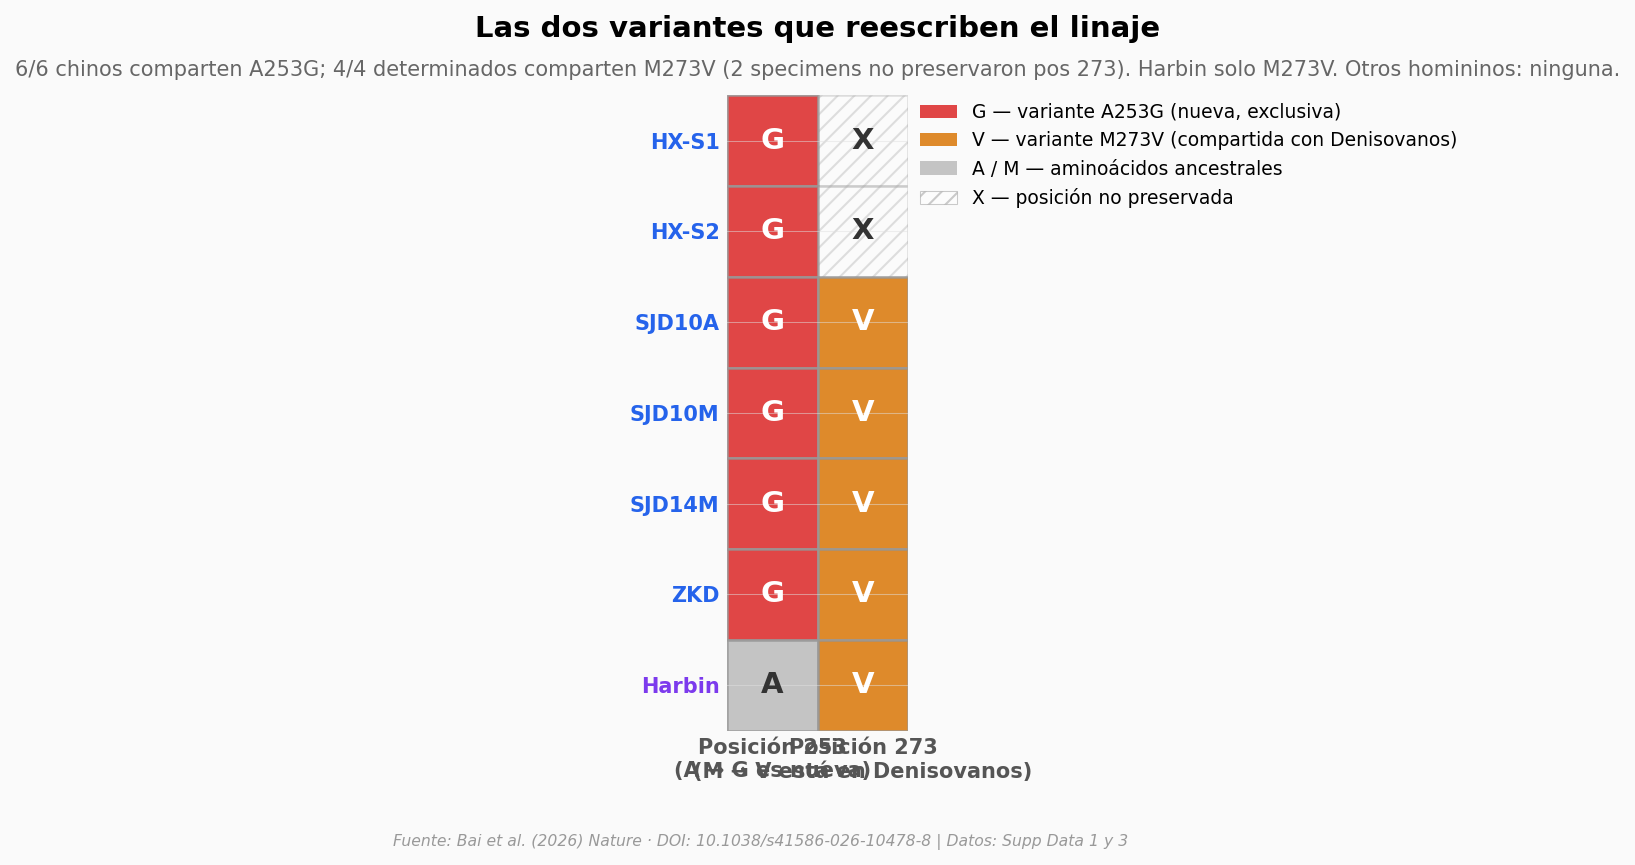

Posición 253: 6/6 chinos con G (variante A253G) — 100%
Posición 273: 4/4 chinos determinados con V (2 no preservaron la posición) — 100% de los determinados


In [4]:
# Construir matriz de variantes en pos 253 y 273
# Filas: specimens (chinos arriba, Harbin abajo). Columnas: pos 253, pos 273
df_var = variantes.copy()

fig, ax = plt.subplots(figsize=(11, 5.5))

# Colores por aminoácido
aa_colors = {
    'G': COLOR_ALERTA,    # Variante NUEVA (A253G) — los 6 chinos
    'A': COLOR_CONTEXTO,  # Ancestral en pos 253 (Harbin, otros homininos)
    'V': COLOR_DENISOVA,  # Compartido con Denisovanos (M273V)
    'M': COLOR_CONTEXTO,  # Ancestral en pos 273
    'X': '#FFFFFF',       # No preservado
}

# Plot manual: rectángulos
specimens_plot = ['HX-S1', 'HX-S2', 'SJD10A', 'SJD10M', 'SJD14M', 'ZKD', 'Harbin']
for i, spec in enumerate(specimens_plot):
    row = df_var[df_var['specimen'] == spec].iloc[0]
    for j, (pos_col, label) in enumerate([('aa_pos253', 'Posición 253'), ('aa_pos273', 'Posición 273')]):
        aa = row[pos_col]
        color = aa_colors.get(aa, '#CCCCCC')
        is_X = (aa == 'X')
        rect = plt.Rectangle((j, len(specimens_plot) - 1 - i), 1, 1,
                             facecolor=color, edgecolor='#999999', linewidth=1.2,
                             alpha=0.85 if not is_X else 0.3, hatch='///' if is_X else None)
        ax.add_patch(rect)
        # Texto con el aminoácido
        ax.text(j + 0.5, len(specimens_plot) - 1 - i + 0.5, aa,
                ha='center', va='center', fontsize=14, fontweight='bold',
                color='white' if (not is_X and aa in ('G', 'V')) else '#333333')

# Ejes
ax.set_xlim(0, 2)
ax.set_ylim(0, len(specimens_plot))
ax.set_xticks([0.5, 1.5])
ax.set_xticklabels(['Posición 253\n(A → G es nueva)', 'Posición 273\n(M → V está en Denisovanos)'],
                   fontsize=10, fontweight='bold')
ax.set_yticks([i + 0.5 for i in range(len(specimens_plot))])
ax.set_yticklabels(specimens_plot[::-1], fontsize=10, fontweight='bold')

# Colorear yticks (Harbin distinto)
for tick, spec in zip(ax.get_yticklabels(), specimens_plot[::-1]):
    tick.set_color(COLOR_HARBIN if spec == 'Harbin' else COLOR_CHINOS)

# Leyenda manual con cajas
legend_elems = [
    plt.Rectangle((0, 0), 1, 1, fc=COLOR_ALERTA, alpha=0.85, label='G — variante A253G (nueva, exclusiva)'),
    plt.Rectangle((0, 0), 1, 1, fc=COLOR_DENISOVA, alpha=0.85, label='V — variante M273V (compartida con Denisovanos)'),
    plt.Rectangle((0, 0), 1, 1, fc=COLOR_CONTEXTO, alpha=0.85, label='A / M — aminoácidos ancestrales'),
    plt.Rectangle((0, 0), 1, 1, fc='white', ec='#999999', hatch='///', alpha=0.5, label='X — posición no preservada'),
]
ax.legend(handles=legend_elems, loc='upper left', bbox_to_anchor=(1.02, 1.0),
          fontsize=9, framealpha=0.9, borderaxespad=0)

ax.set_aspect('equal')
ax.set_title('Las dos variantes que reescriben el linaje',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '6/6 chinos comparten A253G; 4/4 determinados comparten M273V (2 specimens no preservaron pos 273). Harbin solo M273V. Otros homininos: ninguna.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.tick_params(axis='both', length=0)

plt.subplots_adjust(right=0.65)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/03_variantes_ambn.png', dpi=200, bbox_inches='tight')
plt.show()

# Conteos para narrativa
n_253_G = (df_var[df_var['specimen'] != 'Harbin']['aa_pos253'] == 'G').sum()
n_273_V_det = ((df_var[df_var['specimen'] != 'Harbin']['aa_pos273'] == 'V')).sum()
n_273_X = ((df_var[df_var['specimen'] != 'Harbin']['aa_pos273'] == 'X')).sum()
n_273_det = ((df_var[df_var['specimen'] != 'Harbin']['aa_pos273'] != 'X')).sum()
print(f'Posición 253: {n_253_G}/6 chinos con G (variante A253G) — 100%')
print(f'Posición 273: {n_273_V_det}/{n_273_det} chinos determinados con V ({n_273_X} no preservaron la posición) — 100% de los determinados')

## El cromosoma 4 cuenta otra historia

Las proteínas son una vía. La otra es el ADN — pero no de los fósiles chinos (no hay genoma de *H. erectus* del Pleistoceno medio). Para el análisis genómico, el paper compara secuencias **modernas** de un humano contemporáneo contra Denisovano y Neandertal, en una región específica del cromosoma 4 (71.4-71.7 millones de pares de bases) — un *locus* (un tramo concreto del cromosoma, con dirección postal genética fija) que el paper analiza como ejemplo de las regiones con introgresión super-arcaica.

La pregunta: en ese tramo, ¿quién está genéticamente más cerca de los *H. erectus* chinos? El proxy aquí es **similaridad ventana a ventana** — qué tan parecidas son las secuencias en bloques de 20 kilobases.

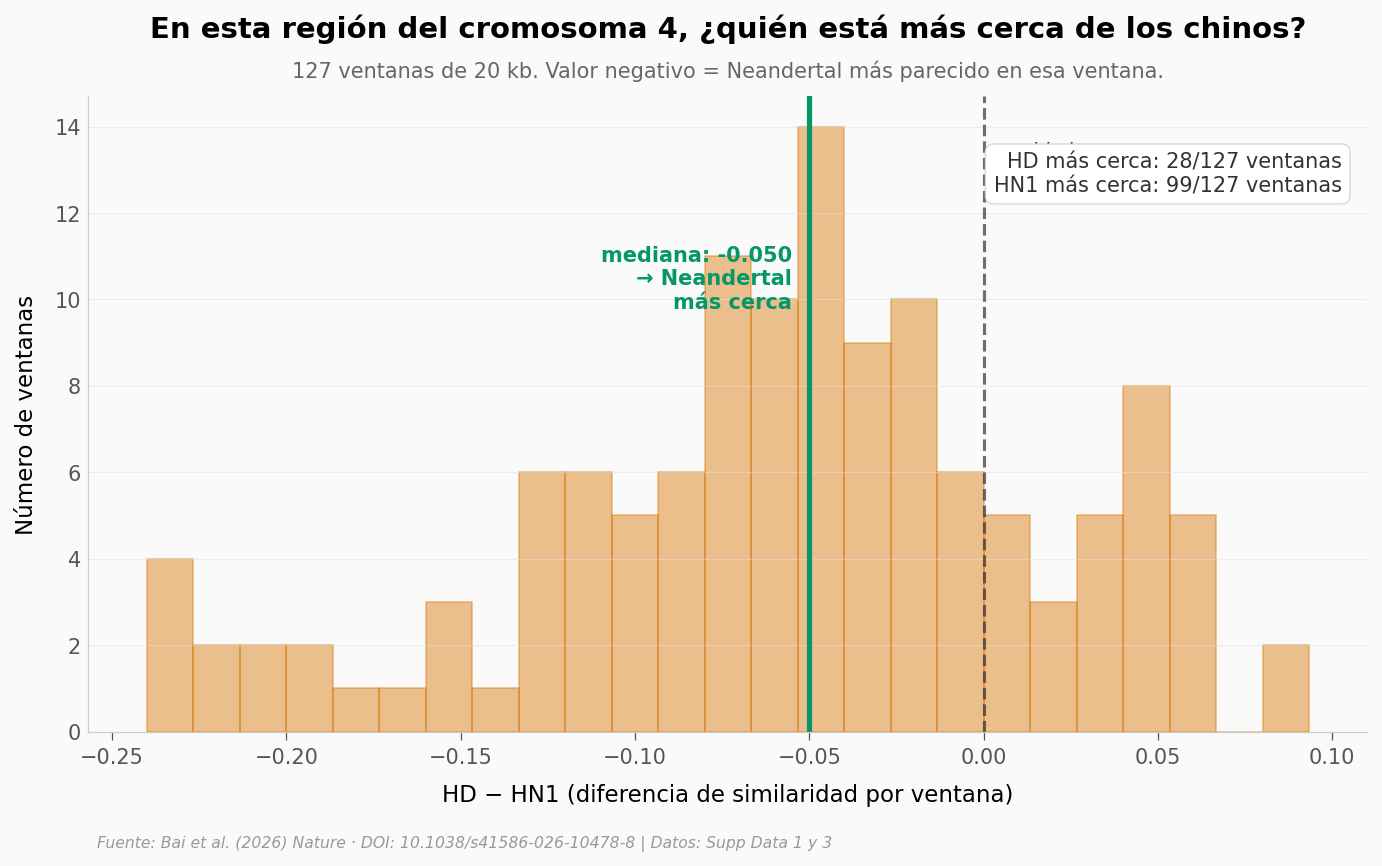

Wilcoxon pareado: W = 1156, p = 2.61e-12
Cohen's d (pareado): -0.751 (magnitud: medio)
Mediana HD − HN1: -0.050
En ESTA región: Neandertal supera a Denisovano en 99/127 ventanas (78.0%)


In [5]:
# Distribución de las dos similaridades + diferencia
HD = similaridad['HD_Similarity'].values   # Denisovano
HN1 = similaridad['HN1_Similarity'].values # Neanderthal
diff = HD - HN1

fig, ax = plt.subplots(figsize=(11, 5.5))

# Histograma de la diferencia HD - HN1
n_bins = 25
n, bins, patches = ax.hist(diff, bins=n_bins, color=COLOR_DENISOVA, alpha=0.45,
                           edgecolor=COLOR_DENISOVA, linewidth=0.8, label='HD − HN1 por ventana')

# Línea vertical en 0 (paridad)
ax.axvline(x=0, color='#333333', linewidth=1.5, linestyle='--', alpha=0.7)
ax.text(0.005, max(n) * 0.95, 'paridad', fontsize=9, color='#333333', style='italic')

# Línea vertical en mediana
median_diff = np.median(diff)
ax.axvline(x=median_diff, color=COLOR_NEAND, linewidth=2.5)
ax.text(median_diff - 0.005, max(n) * 0.7, f'mediana: {median_diff:+.3f}\n→ Neandertal\nmás cerca',
        fontsize=10, fontweight='bold', color=COLOR_NEAND, ha='right')

# Conteo de ventanas a cada lado
n_HD_higher = (diff > 0).sum()
n_HN1_higher = (diff < 0).sum()
ax.text(0.98, 0.85, f'HD más cerca: {n_HD_higher}/{len(diff)} ventanas\nHN1 más cerca: {n_HN1_higher}/{len(diff)} ventanas',
        transform=ax.transAxes, fontsize=10, color='#333333', ha='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#CCCCCC'))

ax.set_xlabel('HD − HN1 (diferencia de similaridad por ventana)', fontsize=11)
ax.set_ylabel('Número de ventanas', fontsize=11)
ax.set_title('En esta región del cromosoma 4, ¿quién está más cerca de los chinos?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '127 ventanas de 20 kb. Valor negativo = Neandertal más parecido en esa ventana.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/04_similaridad_cr4.png', dpi=200, bbox_inches='tight')
plt.show()

# Test estadístico: Wilcoxon pareado (mismas ventanas, dos mediciones)
W, p_wilcox = stats.wilcoxon(HD, HN1)
# Cohen's d pareado
d_paired = diff.mean() / diff.std(ddof=1)
print(f'Wilcoxon pareado: W = {W:.0f}, p = {p_wilcox:.3g}')
print(f"Cohen's d (pareado): {d_paired:.3f} (magnitud: {'pequeño' if abs(d_paired) < 0.5 else 'medio' if abs(d_paired) < 0.8 else 'grande'})")
print(f'Mediana HD − HN1: {median_diff:+.3f}')
print(f'En ESTA región: Neandertal supera a Denisovano en {n_HN1_higher}/{len(diff)} ventanas ({100*n_HN1_higher/len(diff):.1f}%)')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| 6 specimens chinos de 3 sitios dieron proteomas | ✅ | 6/6 specimens en los CSVs (HX-S1, HX-S2, SJD10A, SJD10M, SJD14M, ZKD). El paper enmarca esto como hecho (peer-reviewed). |
| Tasa de éxito MALDI difiere por sitio | ✅ | Zhoukoudian 37.5%, Hexian 35.0%, Sunjiadong 13.5%. Diferencia ~3x entre Sunjiadong y los otros. Test no aplica (descriptivo, n por sitio chico). |
| Los 6 comparten A253G en AMBN | ✅ | 6/6 con G en posición 253. Harbin tiene A. El paper lo plantea como afirmación directa. |
| Los 6 comparten M273V en AMBN | ⚠️ | 4/4 chinos determinados con V; HX-S1 y HX-S2 no preservaron la posición. Compatible con la afirmación, pero el respaldo directo es 4/6. |
| A253G es desconocida en otros linajes humanos | ⚠️ | Verificable parcialmente: Harbin tiene A. Comparación con Dmanisi, Atapuerca, Denisovanos, Neandertales y modernos se basa en referencias del paper, no en nuestros datos. |
| M273V ya conocida en Denisovanos | ⚠️ | Afirmación del paper; nuestros CSVs no contienen Denisovanos. Asumimos referencia previa. |
| Introgresión super-arcaica en Denisovanos vino probablemente de *H. erectus* | ⚠️ | Inferencia compleja. En la ventana cr4 que tenemos, **Neandertal está MÁS cerca de *H. erectus* que Denisovano** en 99 de 127 ventanas (Wilcoxon p ≈ 2.6e-12, Cohen's d ≈ 0.75). El paper enmarca esta región como ejemplo de señal heterogénea — no hay que sobre-leer este locus. |

**Limitaciones:**
- Cobertura proteómica modesta (mediana 18%, media 27% en los chinos) — natural para paleoproteómica de ~400 ka, pero significa que muchas posiciones de cada proteína no se leyeron.
- 2 de 6 chinos no preservaron la posición 273 de AMBN. La afirmación del paper "todos comparten M273V" se sostiene en 4 specimens determinados.
- La similaridad genómica que mostramos es **una región específica del cromosoma 4** (~272 kilobases). Extrapolar al genoma completo requiere mirar muchas más ventanas — el paper lo hace, nosotros no.
- Los datos crudos de MS (PRIDE PXD068897) no se descargaron por tamaño. Confiamos en el procesamiento del paper para las identificaciones de variantes.

## Ahora tú

1. **¿Y si quitamos a Sunjiadong?** Solo con Zhoukoudian y Hexian, ¿se mantiene la tasa de éxito MALDI? Pista: filtra `screening` y recalcula `enamel_positive.sum() / specimens_screened.sum()`.

2. **¿Hay diferencia de cobertura entre proteínas?** AMELX está reportada con ~50% en chinos, pero AHSG con ~5%. Pista: `cobertura.groupby('protein')['coverage_pct'].describe()`.

3. **¿La señal del cromosoma 4 es uniforme?** Mira cómo cambia `HD − HN1` a lo largo de las 127 ventanas — ¿hay regiones donde Denisovano sí está más cerca que Neandertal? Pista: ordena por `Window_Middle` y grafica la diferencia en orden.

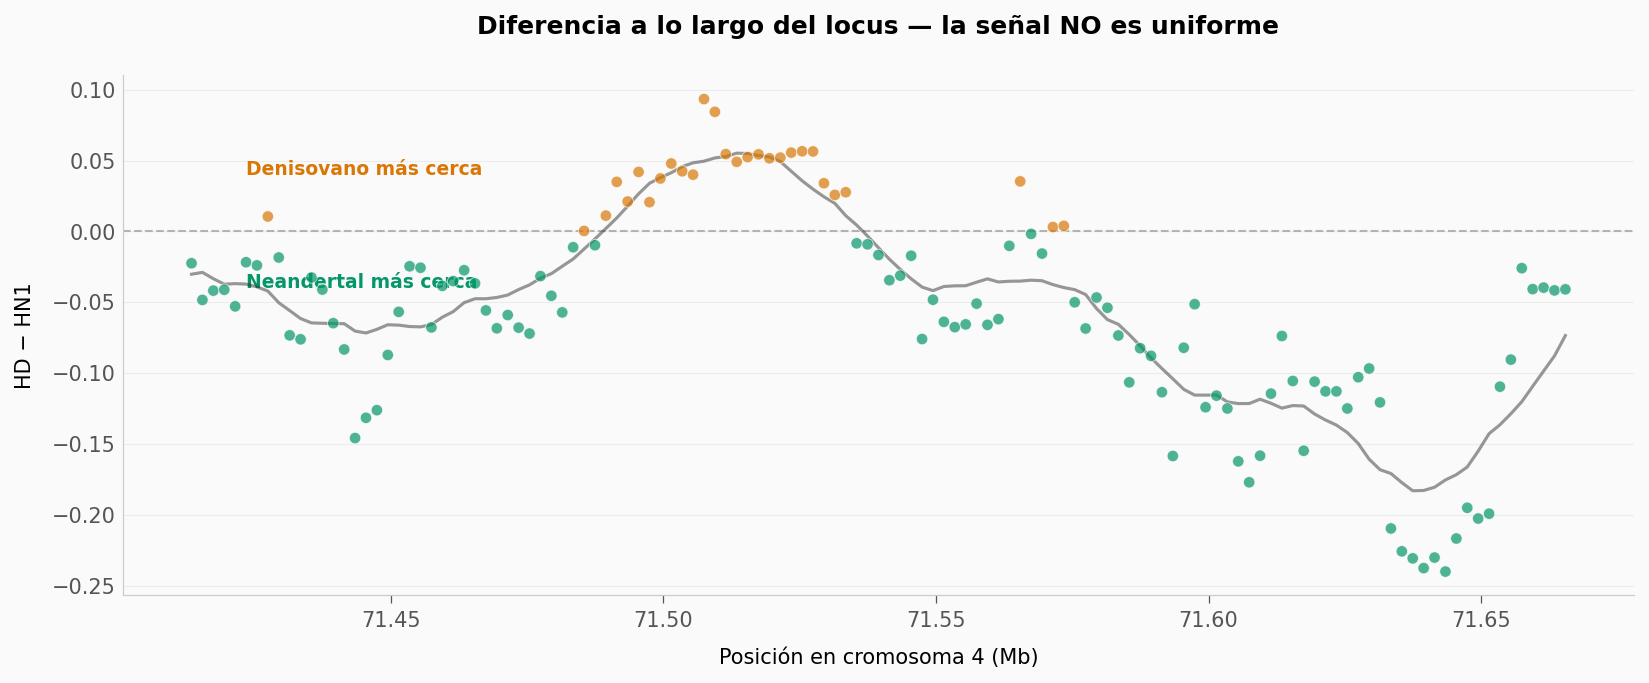

Ventanas con Denisovano más cerca: 28 (22.0%)
Ventanas con Neandertal más cerca: 99 (78.0%)
Ventanas iguales: 0


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Respuesta a la pregunta 3: la señal a lo largo del cromosoma 4

fig, ax = plt.subplots(figsize=(13, 4.5))

window_mb = similaridad['Window_Middle'].values / 1e6  # convertir a Mb para legibilidad
diff_along = similaridad['HD_Similarity'].values - similaridad['HN1_Similarity'].values

# Colorear puntos por signo
colors_pts = [COLOR_DENISOVA if d > 0 else COLOR_NEAND for d in diff_along]
ax.scatter(window_mb, diff_along, c=colors_pts, s=30, alpha=0.7, edgecolors='white', linewidths=0.4, zorder=5)

# Línea suavizada (rolling)
df_smooth = pd.Series(diff_along).rolling(15, center=True, min_periods=1).mean()
ax.plot(window_mb, df_smooth, color='#333333', linewidth=1.5, alpha=0.5, zorder=4)

ax.axhline(y=0, color='#999999', linewidth=1.0, linestyle='--', alpha=0.7)
ax.set_xlabel('Posición en cromosoma 4 (Mb)', fontsize=10)
ax.set_ylabel('HD − HN1', fontsize=10)
ax.set_title('Diferencia a lo largo del locus — la señal NO es uniforme',
             fontsize=12, fontweight='bold', pad=20)

# Inline labels
ax.text(window_mb[5], 0.04, 'Denisovano más cerca', color=COLOR_DENISOVA, fontsize=9, fontweight='bold')
ax.text(window_mb[5], -0.04, 'Neandertal más cerca', color=COLOR_NEAND, fontsize=9, fontweight='bold')

plt.savefig('figuras/05_ventana_a_lo_largo.png', dpi=200, bbox_inches='tight')
plt.show()

# Cuenta cuántas ventanas hay con cada patrón
print(f'Ventanas con Denisovano más cerca: {(diff_along > 0).sum()} ({100*(diff_along > 0).mean():.1f}%)')
print(f'Ventanas con Neandertal más cerca: {(diff_along < 0).sum()} ({100*(diff_along < 0).mean():.1f}%)')
print(f'Ventanas iguales: {(diff_along == 0).sum()}')

## Créditos

**Paper**: Bai, F., Wu, Z., Xing, S. & Fu, Q. et al. (2026). *Enamel proteins from six Homo erectus specimens across China*. Nature. DOI: [10.1038/s41586-026-10478-8](https://doi.org/10.1038/s41586-026-10478-8)

**Datos**: Supplementary Data 1 (screening MALDI por specimen) y Supplementary Data 3 (similaridad genómica por ventana cr4) del paper. Datos crudos de espectrometría: ProteomeXchange [PXD068897](https://www.ebi.ac.uk/pride/archive/projects/PXD068897).

**Licencia**: notebook bajo MIT. Los datos del paper bajo la licencia editorial de Nature; los CSVs derivados se redistribuyen como resúmenes de tablas suplementarias del propio paper.

**Repo**: [Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)

## Fuentes

**Paper**: [Enamel proteins from six Homo erectus specimens across China](https://doi.org/10.1038/s41586-026-10478-8)  
*Nature, 2026-05-13*

**Source Data** (espectrometría cruda): [Mass spectrometry raw data — six H. erectus enamel proteomes](https://www.ebi.ac.uk/pride/archive/projects/PXD068897)  
*ProteomeXchange / PRIDE, 2026-05-13*

**Referencias citadas**: dataset de referencia paleoproteómica · [Hominid Palaeoproteomic Reference Dataset](https://doi.org/10.5281/zenodo.7728060)

*17 afirmaciones del notebook verificadas contra estas fuentes*